# Mixture-GP posterior plot via a deep ensemble of NanoTabPFN-CTF regressors

Reproduces the posterior plot from `mixture_gp_vi/mixture_gp.ipynb` (PyMC mixture-of-GPs + ADVI) using a fundamentally different inference scheme: K=5 randomly-initialized `NanoTabPFNCtfRegressor` models, each fit directly to the observed `(x, y)` data (no meta-training on a synthetic prior). The CTF wrapper is used in factual-only / no-confounder mode (`d_z=0`, `X'=X`), so it behaves as a standard regression model. The ensemble's spread on `x_new` plays the role of the variational posterior band.

In [21]:
import numpy as np
import scipy.io
import torch
import matplotlib.pyplot as plt

from model import NanoTabPFNModel
from riemann import RiemannDistribution
from ctf_prior import uniform_boundaries
from train_ctf import train_ctf_family, set_randomness_seed, get_default_device
from ctf_model import CtfPFNFamily

device = get_default_device()
print('device:', device)

device: mps


In [22]:
obs = scipy.io.loadmat('mixture_gp_vi/obs.mat')
exp_data = scipy.io.loadmat('mixture_gp_vi/exp.mat')
x = obs['x'][0].astype(np.float32)
y = obs['y'][0].astype(np.float32)
x_new = exp_data['x'][0].astype(np.float32)
y_new = exp_data['y'][0].astype(np.float32)
print('x:    ', x.shape,     'range', (float(x.min()),     float(x.max())))
print('y:    ', y.shape,     'range', (float(y.min()),     float(y.max())))
print('x_new:', x_new.shape, 'range', (float(x_new.min()), float(x_new.max())))
print('y_new:', y_new.shape, 'range', (float(y_new.min()), float(y_new.max())))

x:     (100,) range (-1.3818259239196777, 1.4664288759231567)
y:     (100,) range (9.802356362342834e-05, 6.4512410163879395)
x_new: (100,) range (-2.0, 2.0)
y_new: (100,) range (-3.958247661590576, 8.346578598022461)


In [ ]:
K_FAMILY = 5
NUM_STEPS = 1500
NUM_BUCKETS = 60
EMBEDDING_SIZE = 64
NUM_LAYERS = 3
NUM_HEADS = 4
MLP_HIDDEN = 128
D_Z = 0
N_TRAIN_MIN = 40
N_TRAIN_MAX = 80

# Counterfactual repulsion training.
CF_FRACTION = 0.5         # fraction of test rows that become CF (X' != X)
DIVERSITY_WEIGHT = 0.005   # λ_div: loss = CE_factual - λ_div · mean_{cf rows}((μ_curr - μ̄_prev)²)

# Per-model intervention-smoothness penalty: on CF rows, perturb the X' column
# by δ ~ N(0, σ²) and penalize the squared change of the predicted Riemann mean.
# Encodes continuity in x_intervention: close x1, x0 ⇒ close P(Y_{x}|x').
SMOOTHNESS_WEIGHT = 0.1
SMOOTHNESS_SIGMA = 0.05

# Native-range buckets covering [-10, 10] to match the mixture_gp plot's ylim.
boundaries = uniform_boundaries(NUM_BUCKETS, lo=-10.0, hi=10.0)
riemann = RiemannDistribution(boundaries)
print('num_buckets:', riemann.num_buckets, '| bucket width:', float(riemann.widths[0]))

num_buckets: 60 | bucket width: 0.33333301544189453


In [24]:
class MixtureGPDatasetLoader:
    """Yields random train/test splits of a fixed (x, y) dataset.

    With cf_fraction > 0, a fraction of the test rows are converted into
    counterfactual queries: their X' column is replaced with a value sampled
    from the empirical X distribution (so X' != X), and factual_mask=False
    marks them. The training loop uses factual_mask to apply CE only on
    factual rows and the repulsion penalty only on CF rows.

    Output dict matches the train_ctf prior contract:
      x: (1, N, 2)  features = [X, X'] (d_z=0). For CF rows, X' != X.
      y: (1, N)     observed targets in native scale.
      train_test_split_index: int in [n_train_min, n_train_max].
      factual_mask: (1, N)  True on factual rows, False on CF test rows.
    """

    def __init__(self, x, y, num_steps, n_train_min, n_train_max,
                 cf_fraction=0.0, seed=0, device='cpu'):
        x = np.asarray(x, dtype=np.float32).reshape(-1)
        y = np.asarray(y, dtype=np.float32).reshape(-1)
        assert x.shape == y.shape
        self.N = x.shape[0]
        self.x_col = torch.from_numpy(x)                              # (N,)
        self.x_feat = torch.from_numpy(np.stack([x, x], axis=1))      # (N, 2)
        self.y_full = torch.from_numpy(y)                              # (N,)
        self.num_steps = num_steps
        self.n_train_min = n_train_min
        self.n_train_max = n_train_max
        self.cf_fraction = float(cf_fraction)
        self.seed = seed
        self.device = device

    def __iter__(self):
        gen = torch.Generator(device='cpu')
        gen.manual_seed(self.seed)
        for _ in range(self.num_steps):
            perm = torch.randperm(self.N, generator=gen)
            x_batch = self.x_feat[perm].clone().unsqueeze(0)       # (1, N, 2)
            y_batch = self.y_full[perm].unsqueeze(0)               # (1, N)
            n_train = int(torch.randint(self.n_train_min, self.n_train_max + 1, (1,), generator=gen).item())
            factual_mask = torch.ones(1, self.N, dtype=torch.bool)

            if self.cf_fraction > 0:
                n_test = self.N - n_train
                n_cf = int(round(self.cf_fraction * n_test))
                if n_cf > 0:
                    cf_local = torch.randperm(n_test, generator=gen)[:n_cf]
                    cf_global = n_train + cf_local
                    src_idx = torch.randint(0, self.N, (n_cf,), generator=gen)
                    x_batch[0, cf_global, 1] = self.x_col[src_idx]
                    factual_mask[0, cf_global] = False

            yield {
                'x': x_batch.to(self.device),
                'y': y_batch.to(self.device),
                'train_test_split_index': n_train,
                'factual_mask': factual_mask.to(self.device),
            }

    def __len__(self):
        return self.num_steps

In [25]:
def prior_factory(seed):
    return MixtureGPDatasetLoader(
        x=x, y=y,
        num_steps=NUM_STEPS,
        n_train_min=N_TRAIN_MIN,
        n_train_max=N_TRAIN_MAX,
        cf_fraction=CF_FRACTION,
        seed=seed + 20000,
        device=device,
    )

def diversify_init(model, seed, gain_lo=0.7, gain_hi=1.4):
    """Re-initialize every 2D PFN weight tensor with a per-model random gain.

    The default seed-driven init already varies across family members, but the
    resulting weights tend to live in the same loss basin and members collapse
    to similar functions at X' != X (the §6 failure mode in figure_ctf.ipynb).
    Here each weight tensor is redrawn from a Kaiming-style normal whose gain
    is uniformly sampled per tensor in [gain_lo, gain_hi]. Different seeds give
    different gain sequences and different noise draws, pushing members into
    distinct neighborhoods of parameter space at the start of training.
    """
    gen = torch.Generator(device='cpu')
    gen.manual_seed(seed)
    with torch.no_grad():
        for p in model.parameters():
            if p.ndim < 2:
                continue  # biases & LayerNorm scales: keep defaults
            fan_in = int(p.shape[1])
            u = float(torch.rand((), generator=gen).item())
            gain = gain_lo + (gain_hi - gain_lo) * u
            new_w = torch.randn(p.shape, generator=gen) * (gain / (fan_in ** 0.5))
            p.data.copy_(new_w.to(p.device, dtype=p.dtype))

def model_factory(seed):
    set_randomness_seed(seed)
    model = NanoTabPFNModel(
        embedding_size=EMBEDDING_SIZE,
        num_attention_heads=NUM_HEADS,
        mlp_hidden_size=MLP_HIDDEN,
        num_layers=NUM_LAYERS,
        num_outputs=NUM_BUCKETS,
    )
    # diversify_init(model, seed, gain_lo=0.7, gain_hi=1.4)
    return model

# Sanity check: confirm members differ at init.
_m0 = model_factory(0)
_m1 = model_factory(1)
_p0 = torch.cat([p.detach().cpu().flatten() for p in _m0.parameters() if p.ndim >= 2])
_p1 = torch.cat([p.detach().cpu().flatten() for p in _m1.parameters() if p.ndim >= 2])
print(f'init: member 0 vs 1, L2 dist = {float((_p0 - _p1).norm()):.3f}, cosine = {float(torch.nn.functional.cosine_similarity(_p0.unsqueeze(0), _p1.unsqueeze(0)).item()):.4f}')
del _m0, _m1, _p0, _p1

init: member 0 vs 1, L2 dist = 44.738, cosine = -0.0020


In [26]:
import time as _time
import schedulefree as _sf
from torch import nn as _nn


def train_ctf_diverse(
    model, prior, riemann, prev_frozen, diversity_weight,
    smoothness_weight, smoothness_sigma,
    lr, device, steps_per_eval, verbose,
):
    """Train one CtfPFN with CF-repulsion against frozen previously-trained members.

    Loss = CrossEntropy on factual rows
           - λ_div · mean over CF rows of (μ_current - μ̄_prev)²
           + λ_smooth · mean over CF rows of (μ(X') - μ(X' + δ))², δ ~ N(0, σ²)
    where μ is the Riemann posterior mean (riemann.mean of the logits) and
    μ̄_prev averages those means over the frozen prev models. Factual rows skip
    the repulsion and smoothness terms via the cf_mask; CF rows skip CE via
    target=-100. The smoothness term enforces continuity in the intervention
    column on a single model: close interventions ⇒ close P(Y_{x}|x').
    """
    model.to(device).train()
    for m in prev_frozen:
        m.to(device).eval()

    optimizer = _sf.AdamWScheduleFree(model.parameters(), lr=lr, weight_decay=0.0)
    optimizer.train()
    ce = _nn.CrossEntropyLoss(ignore_index=-100)

    train_time = 0.0
    for step, full_data in enumerate(prior):
        t0 = _time.time()
        split = full_data["train_test_split_index"]
        x_full = full_data["x"].to(device)
        y_full = full_data["y"].to(device)
        factual_mask = full_data["factual_mask"].to(device)
        data = (x_full, y_full[:, :split])

        output = model(data, train_test_split_index=split)  # (B, N_test, K_buckets)
        K_buckets = output.shape[-1]
        output_flat = output.reshape(-1, K_buckets)

        # CE on factual test rows (CF rows -> target -100 -> skipped by CE).
        targets = riemann.bucketize(y_full[:, split:].reshape(-1))
        mask_flat = factual_mask[:, split:].reshape(-1)
        targets = torch.where(mask_flat, targets, torch.full_like(targets, -100))
        loss_ce = ce(output_flat, targets)

        # Repulsion on CF rows vs. mean of frozen prev members' Riemann means.
        loss_div = output_flat.new_zeros(())
        cf_mask = ~mask_flat
        if prev_frozen and diversity_weight > 0 and cf_mask.any():
            current_mu = riemann.mean(output_flat)  # (B*N_test,)
            with torch.no_grad():
                prev_mus = []
                for prev in prev_frozen:
                    prev_out = prev(data, train_test_split_index=split).reshape(-1, K_buckets)
                    prev_mus.append(riemann.mean(prev_out))
                prev_avg = torch.stack(prev_mus, dim=0).mean(dim=0)
            sq_dist = (current_mu - prev_avg) ** 2
            loss_div = sq_dist[cf_mask].mean()

        # Intervention smoothness: perturb X' by δ on CF rows only and penalize
        # squared change of predicted Riemann mean. Requires a second forward pass.
        loss_smooth = output_flat.new_zeros(())
        if smoothness_weight > 0 and cf_mask.any():
            cf_full = torch.zeros_like(x_full[..., 1], dtype=torch.bool)
            cf_full[:, split:] = ~factual_mask[:, split:]
            delta = torch.randn_like(x_full[..., 1]) * smoothness_sigma
            x_pert = x_full.clone()
            x_pert[..., 1] = torch.where(cf_full, x_pert[..., 1] + delta, x_pert[..., 1])
            output_pert = model((x_pert, y_full[:, :split]),
                                train_test_split_index=split).reshape(-1, K_buckets)
            mu_orig = riemann.mean(output_flat)
            mu_pert = riemann.mean(output_pert)
            loss_smooth = ((mu_orig - mu_pert) ** 2)[cf_mask].mean()

        loss = loss_ce - diversity_weight * loss_div + smoothness_weight * loss_smooth
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        train_time += _time.time() - t0
        if step % steps_per_eval == steps_per_eval - 1 and verbose:
            ff = float(mask_flat.float().mean().detach().cpu())
            print(
                f"step {step:5d} | time {train_time:7.1f}s | "
                f"loss_ce {float(loss_ce):7.4f} | loss_div {float(loss_div):7.4f} | "
                f"loss_smooth {float(loss_smooth):7.4f} | factual_frac {ff:.2f}"
            )

    model.eval()
    optimizer.eval()
    return model


# Sequential family training: each new member repels from all previous members on CF rows.
models = []
for k, seed in enumerate(range(K_FAMILY)):
    print(f"=== Family member {k+1}/{K_FAMILY} (seed={seed}, vs {len(models)} prev) ===")
    set_randomness_seed(seed)
    model = model_factory(seed)
    prior = prior_factory(seed)
    model = train_ctf_diverse(
        model, prior, riemann,
        prev_frozen=models,
        diversity_weight=DIVERSITY_WEIGHT,
        smoothness_weight=SMOOTHNESS_WEIGHT,
        smoothness_sigma=SMOOTHNESS_SIGMA,
        lr=2e-3,
        device=device,
        steps_per_eval=300,
        verbose=True,
    )
    models.append(model)

=== Family member 1/50 (seed=0, vs 0 prev) ===
step   299 | time    40.1s | loss_ce  0.3884 | loss_div  0.0000 | loss_smooth  0.0253 | factual_frac 0.50
step   599 | time    77.0s | loss_ce  0.1046 | loss_div  0.0000 | loss_smooth  0.0119 | factual_frac 0.50
step   899 | time   113.9s | loss_ce  0.0762 | loss_div  0.0000 | loss_smooth  0.0109 | factual_frac 0.50
step  1199 | time   150.7s | loss_ce  0.1398 | loss_div  0.0000 | loss_smooth  0.0077 | factual_frac 0.50
step  1499 | time   188.0s | loss_ce  0.0096 | loss_div  0.0000 | loss_smooth  0.0114 | factual_frac 0.52
=== Family member 2/50 (seed=1, vs 1 prev) ===
step   299 | time    42.1s | loss_ce  0.1606 | loss_div  2.8793 | loss_smooth  0.0127 | factual_frac 0.48
step   599 | time    84.1s | loss_ce  0.2084 | loss_div  3.8286 | loss_smooth  0.0266 | factual_frac 0.50
step   899 | time   126.2s | loss_ce  0.1171 | loss_div  1.6264 | loss_smooth  0.0236 | factual_frac 0.50
step  1199 | time   166.3s | loss_ce  0.0140 | loss_div  2

In [34]:
import os

# Persist the trained K-member family so the long training run is reusable.
# Saves state_dicts + architecture + Riemann boundaries; reload by rebuilding
# NanoTabPFNModel with `arch` and `load_state_dict(sd)`, then re-wrapping in
# CtfPFNFamily(models, RiemannDistribution(boundaries), device=device, d_z=d_z).
SAVE_PATH = 'mixture_gp_ctf_family.pt'
torch.save({
    'state_dicts': [m.state_dict() for m in models],
    'arch': dict(
        embedding_size=EMBEDDING_SIZE,
        num_attention_heads=NUM_HEADS,
        mlp_hidden_size=MLP_HIDDEN,
        num_layers=NUM_LAYERS,
        num_outputs=NUM_BUCKETS,
    ),
    'boundaries': boundaries.detach().cpu() if torch.is_tensor(boundaries) else torch.as_tensor(boundaries),
    'd_z': D_Z,
}, SAVE_PATH)
print(f'saved {len(models)} models -> {SAVE_PATH} ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)')

saved 50 models -> mixture_gp_ctf_family.pt (34.6 MB)


In [ ]:
# Alternative to retraining: load a previously-saved family. If you run this
# cell, skip the training cell, the save cell, and the family-build cell below
# (this cell already constructs `family` and calls `family.fit`).
SAVE_PATH = 'mixture_gp_ctf_family.pt'
ckpt = torch.load(SAVE_PATH, map_location=device)

models = []
for sd in ckpt['state_dicts']:
    m = NanoTabPFNModel(**ckpt['arch'])
    m.load_state_dict(sd)
    m.to(device).eval()
    models.append(m)

riemann = RiemannDistribution(ckpt['boundaries'])
family = CtfPFNFamily(models, riemann, device=device, d_z=ckpt['d_z'])
family.fit(np.empty((x.shape[0], 0), dtype=np.float32), x, y)
print(f'loaded {len(models)} models from {SAVE_PATH}; family.K = {family.K}, d_z = {ckpt["d_z"]}')

In [27]:
family = CtfPFNFamily(models, riemann, device=device, d_z=D_Z)

Z_train_empty = np.empty((x.shape[0], 0), dtype=np.float32)
Z_new_empty   = np.empty((x_new.shape[0], 0), dtype=np.float32)

family.fit(Z_train_empty, x, y)

# Factual-style query: X' = X (no intervention).
result = family.predict_counterfactual_family(Z_new_empty, x_new, x_new)
print('ensemble_mean shape:', result['ensemble_mean'].shape)
print('envelope_lo/hi shape:', result['envelope_lo'].shape)
print('per-model means shape:', result['means'].shape)

# Sanity check: predict at training x.
result_train = family.predict_counterfactual_family(Z_train_empty, x, x)
train_mae = float(np.mean(np.abs(result_train['ensemble_mean'] - y)))
print(f'training-data MAE (ensemble mean vs observed y): {train_mae:.3f}')
print(f'bucket-discretization floor: {20/NUM_BUCKETS:.3f}')

ensemble_mean shape: (100,)
envelope_lo/hi shape: (100,)
per-model means shape: (50, 100)
training-data MAE (ensemble mean vs observed y): 0.085
bucket-discretization floor: 0.333


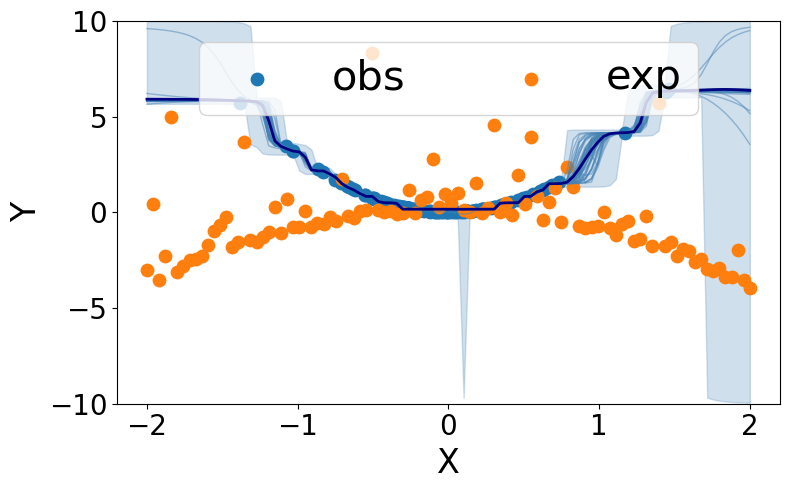

In [28]:
fig = plt.figure(figsize=(8, 5))
ax = fig.gca()

order = np.argsort(x_new)
xn = x_new[order]
em = result['ensemble_mean'][order]
elo = result['envelope_lo'][order]
ehi = result['envelope_hi'][order]
per_model = result['means'][:, order]

ax.fill_between(xn, elo, ehi, alpha=0.25, color='steelblue')
for k in range(family.K):
    ax.plot(xn, per_model[k], color='steelblue', alpha=0.5, linewidth=1)
ax.plot(xn, em, color='navy', linewidth=2)

ax.scatter(x, y, label='obs', s=80)
ax.scatter(x_new, y_new, label='exp', s=80)

ax.set_xlabel('X', fontsize=24)
ax.set_ylabel('Y', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_ylim([-10, 10])
ax.legend(loc='upper center', ncol=2, fontsize=30)

plt.tight_layout()
plt.savefig('mixture_gp_ctf_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

# Posterior over the interventional expectation $E[Y\mid do(x)]$

The plot above shows the *factual-style* prediction at each query point (`X_test = X_intervention = x_new`). Here we instead compute the **interventional** expectation via the adjustment formula:

$$E[Y \mid do(x)] \;=\; \sum_{x'} E[Y_x \mid X = x']\,P(x'),$$

using the empirical $P(x')$ over the observed training $x$. Concretely, for each target intervention $x \in $ `x_new`, we average the family's counterfactual prediction $E[Y_x \mid X = x_i]$ over all observed $x_i$. The K=10 ensemble members each give one such marginalized curve; their spread is the posterior over $E[Y\mid do(x)]$.

In [37]:
N = x.shape[0]
N_new = x_new.shape[0]
Z_query_empty = np.empty((N, 0), dtype=np.float32)

# (K, N_new): posterior over E[Y|do(x_target)], one curve per ensemble member.
e_do_per_k = np.empty((family.K, N_new), dtype=np.float32)

for j, x_target in enumerate(x_new):
    X_int = np.full(N, x_target, dtype=np.float32)
    res = family.predict_counterfactual_family(Z_query_empty, x, X_int)
    # res['means']: (K, N) — row i for member k is E[Y_{x_target} | X = x_i].
    # Empirical P(x') is uniform 1/N over training x, so average across rows.
    e_do_per_k[:, j] = res['means'].mean(axis=1)

# Treat the K ensemble curves as samples from the posterior over E[Y|do(x)].
# 95% Gaussian CI: μ̂ ± 1.96 · σ̂, with σ̂ the sample SD across the K members.
ensemble_mean_do = e_do_per_k.mean(axis=0)
ensemble_std_do = e_do_per_k.std(axis=0, ddof=1)
Z_CI = 1.96
ci_lo_do = ensemble_mean_do - Z_CI * ensemble_std_do
ci_hi_do = ensemble_mean_do + Z_CI * ensemble_std_do

print('e_do_per_k shape:', e_do_per_k.shape)
print('ensemble_mean_do range:', (float(ensemble_mean_do.min()), float(ensemble_mean_do.max())))
print('ci_width range:', (float((ci_hi_do - ci_lo_do).min()), float((ci_hi_do - ci_lo_do).max())))

e_do_per_k shape: (50, 100)
ensemble_mean_do range: (0.39832988381385803, 4.381453037261963)
ci_width range: (4.131138801574707, 16.292987823486328)


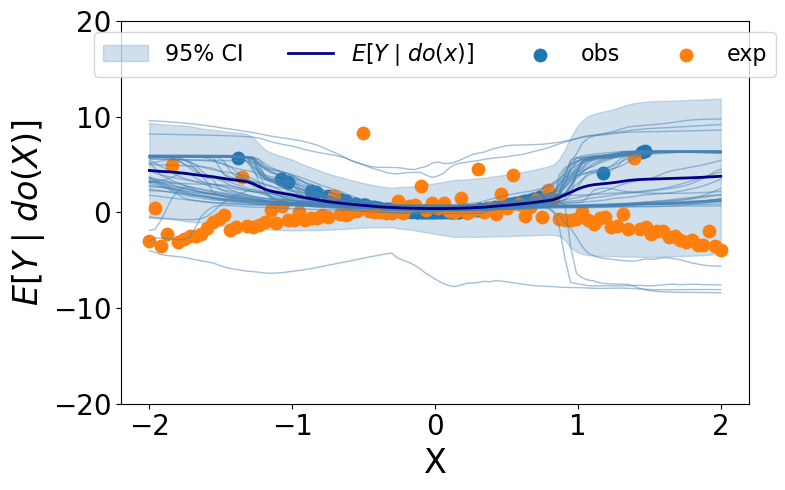

In [35]:
fig = plt.figure(figsize=(8, 5))
ax = fig.gca()

order = np.argsort(x_new)
xn = x_new[order]
em = ensemble_mean_do[order]
elo = ci_lo_do[order]
ehi = ci_hi_do[order]
per_model = e_do_per_k[:, order]

ax.fill_between(xn, elo, ehi, alpha=0.25, color='steelblue', label='95% CI')
for k in range(family.K):
    ax.plot(xn, per_model[k], color='steelblue', alpha=0.5, linewidth=1)
ax.plot(xn, em, color='navy', linewidth=2, label=r'$E[Y\mid do(x)]$')

ax.scatter(x, y, label='obs', s=80)
ax.scatter(x_new, y_new, label='exp', s=80)

ax.set_xlabel('X', fontsize=24)
ax.set_ylabel(r'$E[Y\mid do(X)]$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_ylim([-20, 20])
ax.legend(loc='upper center', ncol=4, fontsize=16)

plt.tight_layout()
plt.savefig('mixture_gp_ctf_do_posterior.png', dpi=150, bbox_inches='tight')
plt.show()